# Aqueous Solubility Prediction (ESOL Dataset)

## Objective
Predict the aqueous solubility (logS) of molecules from their chemical structure.
Dataset: Delaney (2004) — 1128 molecules with experimentally measured solubility.

## Approach
1. Data loading and exploration
2. Molecular descriptor calculation with RDKit
3. ML model training and comparison
4. Results visualization

## 1. Imports and Dependencies
Loading required libraries:
- **RDKit**: molecular manipulation from SMILES representations
- **scikit-learn**: ML models and evaluation metrics
- **pandas/numpy**: data manipulation and numerical computation
- **matplotlib/seaborn**: visualization

In [11]:
# Librairies de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# RDKit - manipulation de molécules
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print("Toutes les librairies sont importées avec succès !")

Toutes les librairies sont importées avec succès !


## 2. Data Loading
ESOL dataset (Delaney, 2004) — 1128 molecules with experimentally measured
aqueous solubility (logS in mol/L). Loaded directly from the DeepChem repository.

In [12]:
# Chargement du dataset ESOL (Delaney 2004)
url = "https://raw.githubusercontent.com/deepchem/deepchem/master/datasets/delaney-processed.csv"
df = pd.read_csv(url)

print(f"Dimensions du dataset : {df.shape}")
print(f"\nColonnes : {df.columns.tolist()}")
print(f"\nPremières lignes :")
df.head()

Dimensions du dataset : (1128, 10)

Colonnes : ['Compound ID', 'ESOL predicted log solubility in mols per litre', 'Minimum Degree', 'Molecular Weight', 'Number of H-Bond Donors', 'Number of Rings', 'Number of Rotatable Bonds', 'Polar Surface Area', 'measured log solubility in mols per litre', 'smiles']

Premières lignes :


,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O)
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.33,c1ccsc1


In [13]:
# Chargement AqSolDB
df_aqsol = pd.read_csv('../data/curated-solubility-dataset.csv')
print(df_aqsol.shape)
print(df_aqsol.columns.tolist())
df_aqsol.head()

(9982, 26)
['ID', 'Name', 'InChI', 'InChIKey', 'SMILES', 'Solubility', 'SD', 'Ocurrences', 'Group', 'MolWt', 'MolLogP', 'MolMR', 'HeavyAtomCount', 'NumHAcceptors', 'NumHDonors', 'NumHeteroatoms', 'NumRotatableBonds', 'NumValenceElectrons', 'NumAromaticRings', 'NumSaturatedRings', 'NumAliphaticRings', 'RingCount', 'TPSA', 'LabuteASA', 'BalabanJ', 'BertzCT']


,ID,Name,InChI,InChIKey,SMILES,Solubility,SD,Ocurrences,Group,MolWt,...,NumRotatableBonds,NumValenceElectrons,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,RingCount,TPSA,LabuteASA,BalabanJ,BertzCT
0,A-3,"N,N,N-trimethyloctadecan-1-aminium bromide",InChI=1S/C21H46N.BrH/c1-5-6-7-8-9-10-11-12-13-...,SZEMGTQCPRNXEG-UHFFFAOYSA-M,[Br-].CCCCCCCCCCCCCCCCCC[N+](C)(C)C,-3.616127,0.0,1,G1,392.510,...,17.0,142.0,0.0,0.0,0.0,0.0,0.00,158.520601,0.000000e+00,210.377334
1,A-4,Benzo[cd]indol-2(1H)-one,InChI=1S/C11H7NO/c13-11-8-5-1-3-7-4-2-6-9(12-1...,GPYLCFQEKPUWLD-UHFFFAOYSA-N,O=C1Nc2cccc3cccc1c23,-3.254767,0.0,1,G1,169.183,...,0.0,62.0,2.0,0.0,1.0,3.0,29.10,75.183563,2.582996e+00,511.229248
2,A-5,4-chlorobenzaldehyde,InChI=1S/C7H5ClO/c8-7-3-1-6(5-9)2-4-7/h1-5H,AVPYQKSLYISFPO-UHFFFAOYSA-N,Clc1ccc(C=O)cc1,-2.177078,0.0,1,G1,140.569,...,1.0,46.0,1.0,0.0,0.0,1.0,17.07,58.261134,3.009782e+00,202.661065
3,A-8,"zinc bis[2-hydroxy-3,5-bis(1-phenylethyl)benzo...",InChI=1S/2C23H22O3.Zn/c2*1-15(17-9-5-3-6-10-17...,XTUPUYCJWKHGSW-UHFFFAOYSA-L,[Zn++].CC(c1ccccc1)c2cc(C(C)c3ccccc3)c(O)c(c2)...,-3.924409,0.0,1,G1,756.226,...,10.0,264.0,6.0,0.0,0.0,6.0,120.72,323.755434,2.322963e-07,1964.648666
4,A-9,4-({4-[bis(oxiran-2-ylmethyl)amino]phenyl}meth...,InChI=1S/C25H30N2O4/c1-5-20(26(10-22-14-28-22)...,FAUAZXVRLVIARB-UHFFFAOYSA-N,C1OC1CN(CC2CO2)c3ccc(Cc4ccc(cc4)N(CC5CO5)CC6CO...,-4.662065,0.0,1,G1,422.525,...,12.0,164.0,2.0,4.0,4.0,6.0,56.60,183.183268,1.084427e+00,769.899934


## 3. Data Exploration
Checking the distribution of logS values.
Note: the dataset is imbalanced — very few highly soluble molecules (logS > 0),
which explains the poorer model performance in that region.

Statistiques descriptives :
count    1128.000000
mean       -3.050102
std         2.096441
min       -11.600000
25%        -4.317500
50%        -2.860000
75%        -1.600000
max         1.580000
Name: measured log solubility in mols per litre, dtype: float64


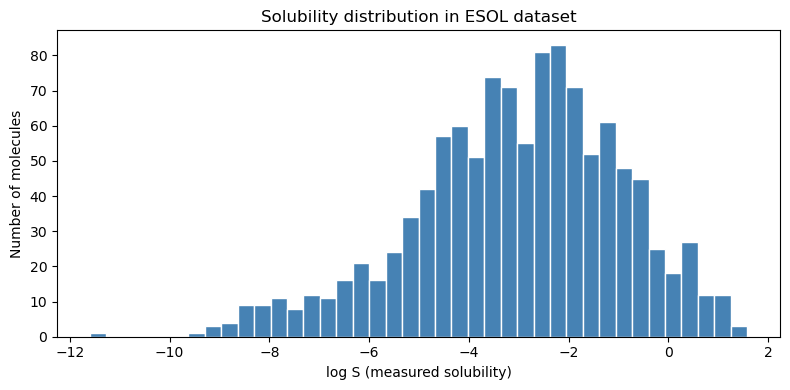

In [14]:
# Statistiques de base
print("Statistiques descriptives :")
print(df['measured log solubility in mols per litre'].describe())

# Distribution de la solubilité
plt.figure(figsize=(8, 4))
plt.hist(df['measured log solubility in mols per litre'], bins=40, color='steelblue', edgecolor='white')
plt.xlabel('log S (measured solubility)')
plt.ylabel('Number of molecules')
plt.title('Solubility distribution in ESOL dataset')
plt.tight_layout()
plt.show()

Statistiques descriptives :
count    9982.000000
mean       -2.889909
std         2.368154
min       -13.171900
25%        -4.326325
50%        -2.618173
75%        -1.209735
max         2.137682
Name: Solubility, dtype: float64


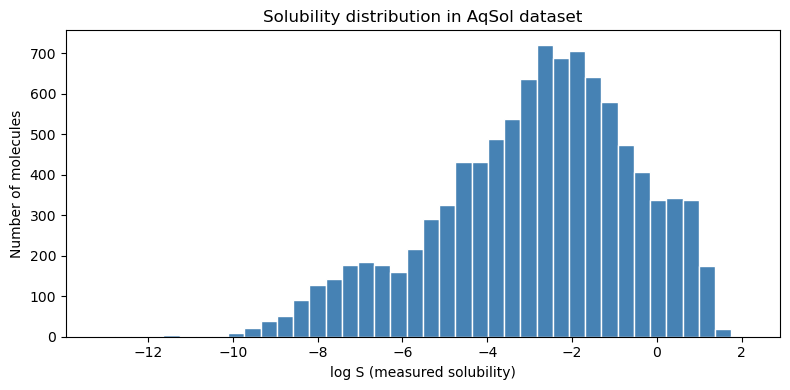

In [15]:
# Statistiques de base
print("Statistiques descriptives :")
print(df_aqsol['Solubility'].describe())

# Distribution de la solubilité
plt.figure(figsize=(8, 4))
plt.hist(df_aqsol['Solubility'], bins=40, color='steelblue', edgecolor='white')
plt.xlabel('log S (measured solubility)')
plt.ylabel('Number of molecules')
plt.title('Solubility distribution in AqSol dataset')
plt.tight_layout()
plt.show()

In [16]:
# Préparer AqSolDB
df_aqsol_clean = df_aqsol[['SMILES', 'Solubility']].rename(
    columns={'SMILES': 'smiles', 'Solubility': 'logS'})

# Préparer ESOL
df_esol_clean = df[['smiles', 'measured log solubility in mols per litre']].rename(
    columns={'measured log solubility in mols per litre': 'logS'})

# Fusionner
df_combined = pd.concat([df_aqsol_clean, df_esol_clean], axis=0, ignore_index=True)

print(f"AqSolDB : {len(df_aqsol_clean)} molécules")
print(f"ESOL : {len(df_esol_clean)} molécules")
print(f"Combined : {len(df_combined)} molécules")
df_combined.head()

df_combined = df_combined.drop_duplicates(subset='smiles').reset_index(drop=True)
print(f"Après suppression des doublons : {len(df_combined)} molécules")

AqSolDB : 9982 molécules
ESOL : 1128 molécules
Combined : 11110 molécules
Après suppression des doublons : 10506 molécules


In [17]:
smiles = df['smiles'].iloc[0]
print(smiles)  # pour voir ce que ça donne
mol = Chem.MolFromSmiles(smiles)
print(mol)

OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)C(O)C3O 


In [18]:
logP = Descriptors.MolLogP(mol)
print(f"LogP de l'Amygdaline : {logP}")

LogP de l'Amygdaline : -3.1080199999999985


## 4. Molecular Descriptor Calculation
Each molecule is represented by 6 physicochemical descriptors computed from its SMILES via RDKit:
- **LogP**: lipophilicity (octanol/water partition coefficient)
- **MolWt**: molecular weight
- **NumHDonors / NumHAcceptors**: hydrogen bonding capacity
- **TPSA**: topological polar surface area
- **NumAromaticRings**: number of aromatic rings

In [19]:
def calculer_descripteurs(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:  # si le SMILES est invalide
        return None
    return {
        'LogP': Descriptors.MolLogP(mol),
        'MolWt': Descriptors.MolWt(mol),
        'NumHDonors': Descriptors.NumHDonors(mol),
        'NumHAcceptors': Descriptors.NumHAcceptors(mol),
        'TPSA': Descriptors.TPSA(mol),
        'NumAromaticRings': rdMolDescriptors.CalcNumAromaticRings(mol)
    }

# Appliquer sur toutes les molécules
descripteurs = df['smiles'].apply(calculer_descripteurs)
descripteurs_df = pd.DataFrame(descripteurs.tolist())
print(descripteurs_df.head())

      LogP    MolWt  NumHDonors  NumHAcceptors    TPSA  NumAromaticRings
0 -3.10802  457.432           7             12  202.32                 1
1  2.84032  201.225           1              2   42.24                 2
2  2.87800  152.237           0              1   17.07                 0
3  6.29940  278.354           0              0    0.00                 5
4  1.74810   84.143           0              1    0.00                 1


In [20]:
dataset = pd.concat([descripteurs_df, df['measured log solubility in mols per litre']], axis=1)
dataset.columns = [*descripteurs_df.columns, 'logS']
print(dataset.shape)
dataset.head()

(1128, 7)


,LogP,MolWt,NumHDonors,NumHAcceptors,TPSA,NumAromaticRings,logS
0,-3.10802,457.432,7,12,202.32,1,-0.77
1,2.84032,201.225,1,2,42.24,2,-3.30
2,2.87800,152.237,0,1,17.07,0,-2.06
3,6.29940,278.354,0,0,0.00,5,-7.87
4,1.74810,84.143,0,1,0.00,1,-1.33


## 5. ML Modelling
Two approaches compared:
- **Linear Regression**: simple baseline model
- **Random Forest**: non-linear model, better suited to complex relationships
between descriptors and solubility

80/20 train/test split with random_state=42 for reproducibility.

In [21]:
# Séparer X et y
X = dataset.drop(columns=['logS'])  # toutes les colonnes sauf logS
y = dataset['logS']  # juste logS

# Séparer train/test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train : {X_train.shape[0]} molécules")
print(f"Test : {X_test.shape[0]} molécules")

Train : 902 molécules
Test : 226 molécules


In [22]:
# Modèle 1 - Régression linéaire
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# Modèle 2 - Random Forest
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

print("Modèles entraînés !")

Modèles entraînés !


In [23]:
# Prédictions sur le test
y_pred_lr = model_lr.predict(X_test)
y_pred_rf = model_rf.predict(X_test)

# Métriques
r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"Régression linéaire → R² : {r2_lr:.3f} | RMSE : {rmse_lr:.3f}")
print(f"Random Forest       → R² : {r2_rf:.3f} | RMSE : {rmse_rf:.3f}")

Régression linéaire → R² : 0.765 | RMSE : 1.054
Random Forest       → R² : 0.859 | RMSE : 0.816


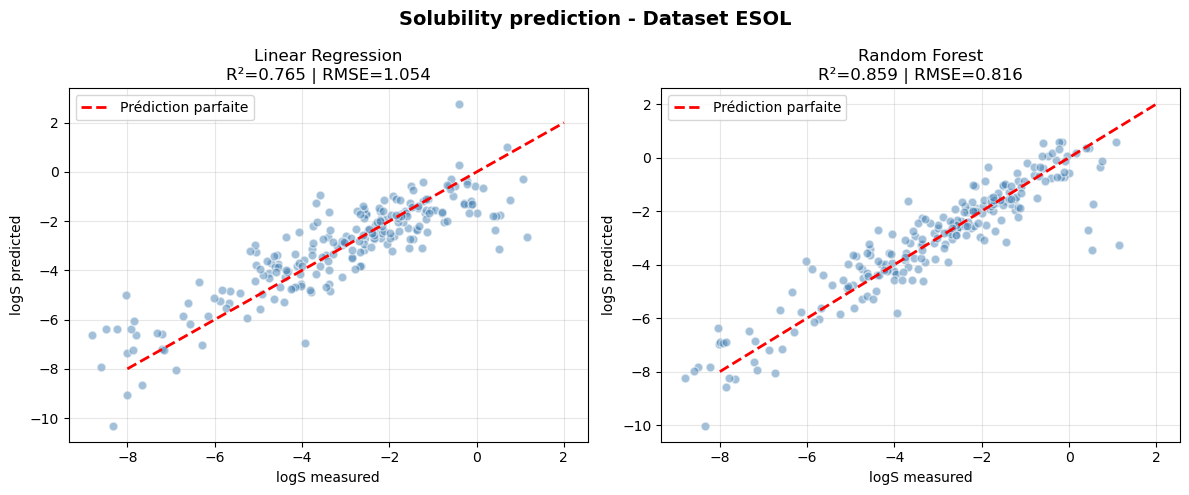

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title, r2, rmse in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ['Linear Regression', 'Random Forest'],
    [r2_lr, r2_rf],
    [rmse_lr, rmse_rf]
):
    ax.scatter(y_test, y_pred, alpha=0.5, color='steelblue', edgecolors='white', s=40)
    ax.plot([-8, 2], [-8, 2], 'r--', linewidth=2, label='Prédiction parfaite')
    ax.set_xlabel('logS measured')
    ax.set_ylabel('logS predicted')
    ax.set_title(f'{title}\nR²={r2:.3f} | RMSE={rmse:.3f}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Solubility prediction - Dataset ESOL', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [25]:
# 1. Calculer les descripteurs de l'aspirine
aspirine_smiles = "CC(=O)Oc1ccccc1C(=O)O"
descripteurs_aspirine = calculer_descripteurs(aspirine_smiles)
print("Descripteurs :", descripteurs_aspirine)

# 2. Mettre dans un DataFrame
X_aspirine = pd.DataFrame([descripteurs_aspirine])

# 3. Prédire
logS_aspirine = model_rf.predict(X_aspirine)
print(f"logS prédit : {logS_aspirine[0]:.3f}")
print(f"logS expérimental : -1.13")
print(f"Erreur : {abs(logS_aspirine[0] - (-1.13)):.3f}")

Descripteurs : {'LogP': 1.3101, 'MolWt': 180.15899999999996, 'NumHDonors': 1, 'NumHAcceptors': 3, 'TPSA': 63.60000000000001, 'NumAromaticRings': 1}
logS prédit : -1.860
logS expérimental : -1.13
Erreur : 0.730


## 6. Improvement: Morgan Fingerprints
Global descriptors do not capture local structural patterns.
Morgan fingerprints (radius=2, 2048 bits) encode the presence/absence of substructures
around each atom. Combined with descriptors, they enrich the molecular representation.

| Model | R² | RMSE |
|---|---|---|
| Linear Regression | 0.765 | 1.054 |
| Random Forest (descriptors) | 0.859 | 0.816 |
| Random Forest (fp + descriptors) | 0.866 | 0.795 |
| XGBoost (fp + descriptors) | 0.879 | 0.757 |

In [26]:
from rdkit.Chem import AllChem
import numpy as np

def calculer_fingerprint(smiles, radius=2, nbits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=nbits)
    return np.array(fp)

# Test sur l'Amygdaline
fp_test = calculer_fingerprint(df['smiles'].iloc[0])
print(f"Taille du fingerprint : {fp_test.shape}")
print(f"Bits actifs : {fp_test.sum()} sur {len(fp_test)}")

Taille du fingerprint : (2048,)
Bits actifs : 44 sur 2048


In [27]:
# Calculer les fingerprints pour toutes les molécules
fp_matrix = np.array([calculer_fingerprint(s) for s in df['smiles']])
print(f"Matrice de fingerprints : {fp_matrix.shape}")

# Combiner fingerprints + descripteurs
X_combined = np.hstack([fp_matrix, descripteurs_df.values])
print(f"Dataset combiné : {X_combined.shape}")

y = dataset['logS'].values

Matrice de fingerprints : (1128, 2048)
Dataset combiné : (1128, 2054)


In [28]:
# Split train/test
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_combined, y, test_size=0.2, random_state=42)

# Entraîner Random Forest
model_rf_combined = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf_combined.fit(X_train_c,y_train_c)

# Évaluer
y_pred_combined = model_rf_combined.predict(X_test_c)
r2_combined = r2_score(y_test_c, y_pred_combined)
rmse_combined = np.sqrt(mean_squared_error(y_test_c, y_pred_combined))

print(f"RF descripteurs seuls  → R² : {r2_rf:.3f} | RMSE : {rmse_rf:.3f}")
print(f"RF combiné (fp+desc)   → R² : {r2_combined:.3f} | RMSE : {rmse_combined:.3f}")

RF descripteurs seuls  → R² : 0.859 | RMSE : 0.816
RF combiné (fp+desc)   → R² : 0.866 | RMSE : 0.795


## 7. Conclusions and Perspectives
XGBoost with fingerprints achieves the best performance (R²=0.879, RMSE=0.757),
approaching the expected level of experimental noise in solubility data (±0.7 logS).

**Identified limitations:**
- Poor predictions for logS > 0 (underrepresented in the dataset)
- 2D descriptors only — no solvation energy or melting point

**Next steps:**
- Extension to organic solvent solubility
- Integration of DFT-derived descriptors

In [29]:
from xgboost import XGBRegressor

# Entraîner XGBoost
model_xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model_xgb.fit(X_train_c, y_train_c)

# Évaluer
y_pred_xgb = model_xgb.predict(X_test_c)
r2_xgb = r2_score(y_test_c, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test_c, y_pred_xgb))

print(f"RF combiné (fp+desc)   → R² : {r2_combined:.3f} | RMSE : {rmse_combined:.3f}")
print(f"XGBoost combiné        → R² : {r2_xgb:.3f} | RMSE : {rmse_xgb:.3f}")

RF combiné (fp+desc)   → R² : 0.866 | RMSE : 0.795
XGBoost combiné        → R² : 0.879 | RMSE : 0.757


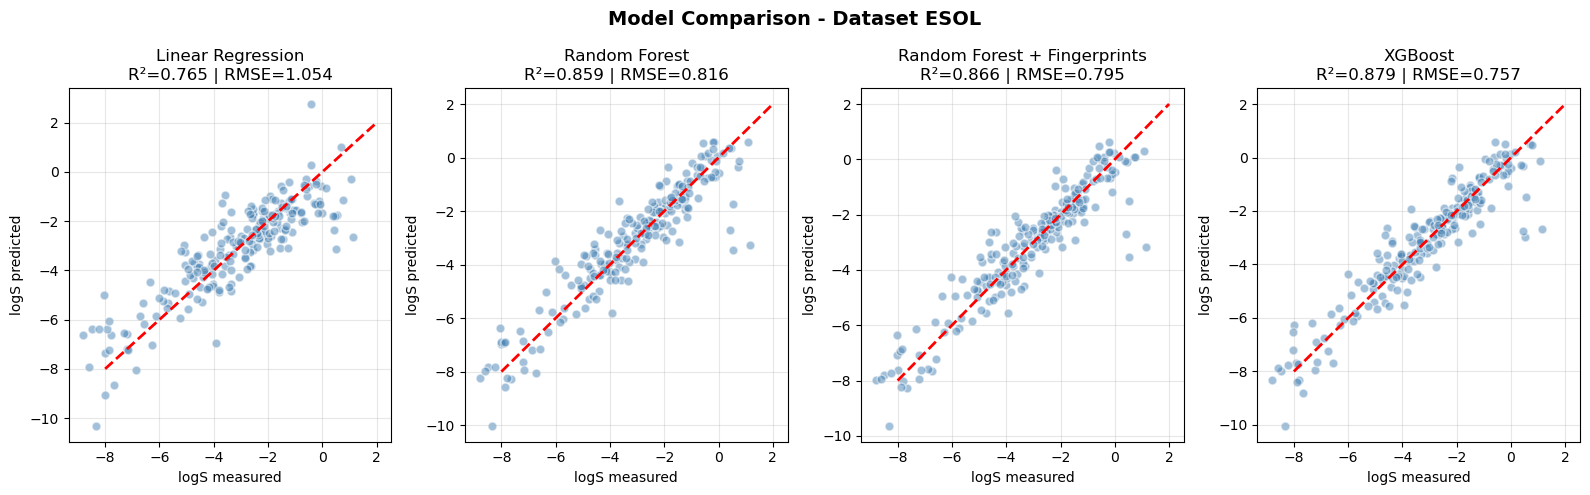

In [30]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, y_pred, title, r2, rmse in zip(
    axes,
    [y_pred_lr, y_pred_rf, y_pred_combined, y_pred_xgb],  # 4 vecteurs de prédictions
    ['Linear Regression', 'Random Forest', 'Random Forest + Fingerprints', 'XGBoost'],  # 4 titres
    [r2_lr, r2_rf, r2_combined, r2_xgb],  # 4 valeurs R²
    [rmse_lr, rmse_rf, rmse_combined, rmse_xgb],  # 4 valeurs RMSE
):
    ax.scatter(y_test_c, y_pred, alpha=0.5, color='steelblue', edgecolors='white', s=40)
    ax.plot([-8, 2], [-8, 2], 'r--', linewidth=2)
    ax.set_xlabel('logS measured')
    ax.set_ylabel('logS predicted')
    ax.set_title(f'{title}\nR²={r2:.3f} | RMSE={rmse:.3f}')
    ax.grid(True, alpha=0.3)

plt.suptitle('Model Comparison - Dataset ESOL', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Scaling Up: Combined Dataset (AqSolDB + ESOL)
Training the best model (XGBoost + fingerprints) on a larger dataset:
- AqSolDB: 9982 molecules
- ESOL: 1128 molecules  
- Combined (after deduplication): 10506 molecules

In [44]:
# Retirer les molécules ESOL du dataset AqSolDB
smiles_esol = set(df_esol_clean['smiles'].tolist())
mask_no_esol = ~df_aqsol_clean['smiles'].isin(smiles_esol)
df_aqsol_no_esol = df_aqsol_clean[mask_no_esol].reset_index(drop=True)

print(f"AqSolDB original : {len(df_aqsol_clean)}")
print(f"AqSolDB sans ESOL : {len(df_aqsol_no_esol)}")
print(f"Molécules retirées : {len(df_aqsol_clean) - len(df_aqsol_no_esol)}")

AqSolDB original : 9982
AqSolDB sans ESOL : 9378
Molécules retirées : 604


In [38]:
# Calculer descripteurs en filtrant les None
desc_list = df_combined['smiles'].apply(calculer_descripteurs).tolist()
valid_mask = [d is not None for d in desc_list]

df_combined_clean = df_combined[valid_mask].reset_index(drop=True)
descripteurs_combined = pd.DataFrame([d for d in desc_list if d is not None])

print(f"Molécules valides : {len(df_combined_clean)} sur {len(df_combined)}")

# Fingerprints
fp_combined = np.array([calculer_fingerprint(s) for s in df_combined_clean['smiles']])

X_big = np.hstack([fp_combined, descripteurs_combined.values])
y_big = df_combined_clean['logS'].values

X_tr, X_te, y_tr, y_te = train_test_split(X_big, y_big, test_size=0.2, random_state=42)
model_xgb_big = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model_xgb_big.fit(X_tr, y_tr)
y_pr = model_xgb_big.predict(X_te)

y_te_big = y_te.copy()
y_pr_big = y_pr.copy()

r2_big = r2_score(y_te, y_pr)
rmse_big = np.sqrt(mean_squared_error(y_te, y_pr))

print(f"XGBoost ESOL only  → R² : {r2_xgb:.3f} | RMSE : {rmse_xgb:.3f}")
print(f"XGBoost Combined   → R² : {r2_big:.3f} | RMSE : {rmse_big:.3f}")

Molécules valides : 10504 sur 10506
XGBoost ESOL only  → R² : 0.879 | RMSE : 0.757
XGBoost Combined   → R² : 0.796 | RMSE : 1.050


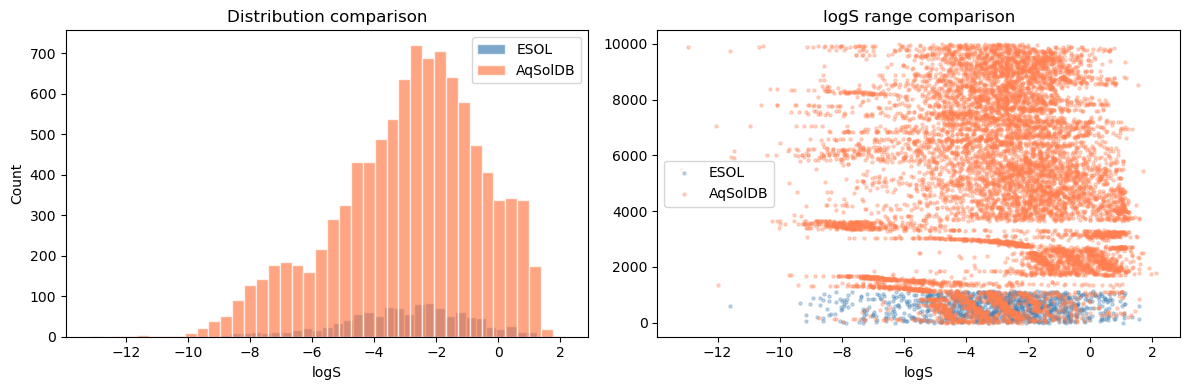

ESOL logS range: -11.60 to 1.58
AqSolDB logS range: -13.17 to 2.14


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_esol_clean['logS'], bins=40, color='steelblue', 
             edgecolor='white', alpha=0.7, label='ESOL')
axes[0].hist(df_aqsol_clean['logS'], bins=40, color='coral', 
             edgecolor='white', alpha=0.7, label='AqSolDB')
axes[0].set_xlabel('logS')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution comparison')
axes[0].legend()

axes[1].scatter(df_esol_clean['logS'], range(len(df_esol_clean)), 
                alpha=0.3, s=5, color='steelblue', label='ESOL')
axes[1].scatter(df_aqsol_clean['logS'], range(len(df_aqsol_clean)), 
                alpha=0.3, s=5, color='coral', label='AqSolDB')
axes[1].set_xlabel('logS')
axes[1].set_title('logS range comparison')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"ESOL logS range: {df_esol_clean['logS'].min():.2f} to {df_esol_clean['logS'].max():.2f}")
print(f"AqSolDB logS range: {df_aqsol_clean['logS'].min():.2f} to {df_aqsol_clean['logS'].max():.2f}")

In [40]:
# Calculer descripteurs en filtrant les None
desc_list_aq = df_aqsol_clean['smiles'].apply(calculer_descripteurs).tolist()
valid_mask_aq = [d is not None for d in desc_list_aq]

df_aq_valid = df_aqsol_clean[valid_mask_aq].reset_index(drop=True)
desc_aq_valid = pd.DataFrame([d for d in desc_list_aq if d is not None])

print(f"Molécules valides : {len(df_aq_valid)} sur {len(df_aqsol_clean)}")

fp_aq = np.array([calculer_fingerprint(s) for s in df_aq_valid['smiles']])
X_aq = np.hstack([fp_aq, desc_aq_valid.values])
y_aq = df_aq_valid['logS'].values

X_tr, X_te, y_tr, y_te = train_test_split(X_aq, y_aq, test_size=0.2, random_state=42)
model_xgb_aq = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model_xgb_aq.fit(X_tr, y_tr)
y_pr_aq = model_xgb_aq.predict(X_te)

r2_aq = r2_score(y_te, y_pr_aq)
rmse_aq = np.sqrt(mean_squared_error(y_te, y_pr_aq))

print(f"XGBoost ESOL only   → R² : {r2_xgb:.3f} | RMSE : {rmse_xgb:.3f}")
print(f"XGBoost AqSolDB     → R² : {r2_aq:.3f} | RMSE : {rmse_aq:.3f}")
print(f"XGBoost Combined    → R² : {r2_big:.3f} | RMSE : {rmse_big:.3f}")

Molécules valides : 9980 sur 9982
XGBoost ESOL only   → R² : 0.879 | RMSE : 0.757
XGBoost AqSolDB     → R² : 0.799 | RMSE : 1.044
XGBoost Combined    → R² : 0.796 | RMSE : 1.050


C:\Users\coure\AppData\Local\Temp\ipykernel_11076\213890832.py:21: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\coure\anaconda3\envs\chemml\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


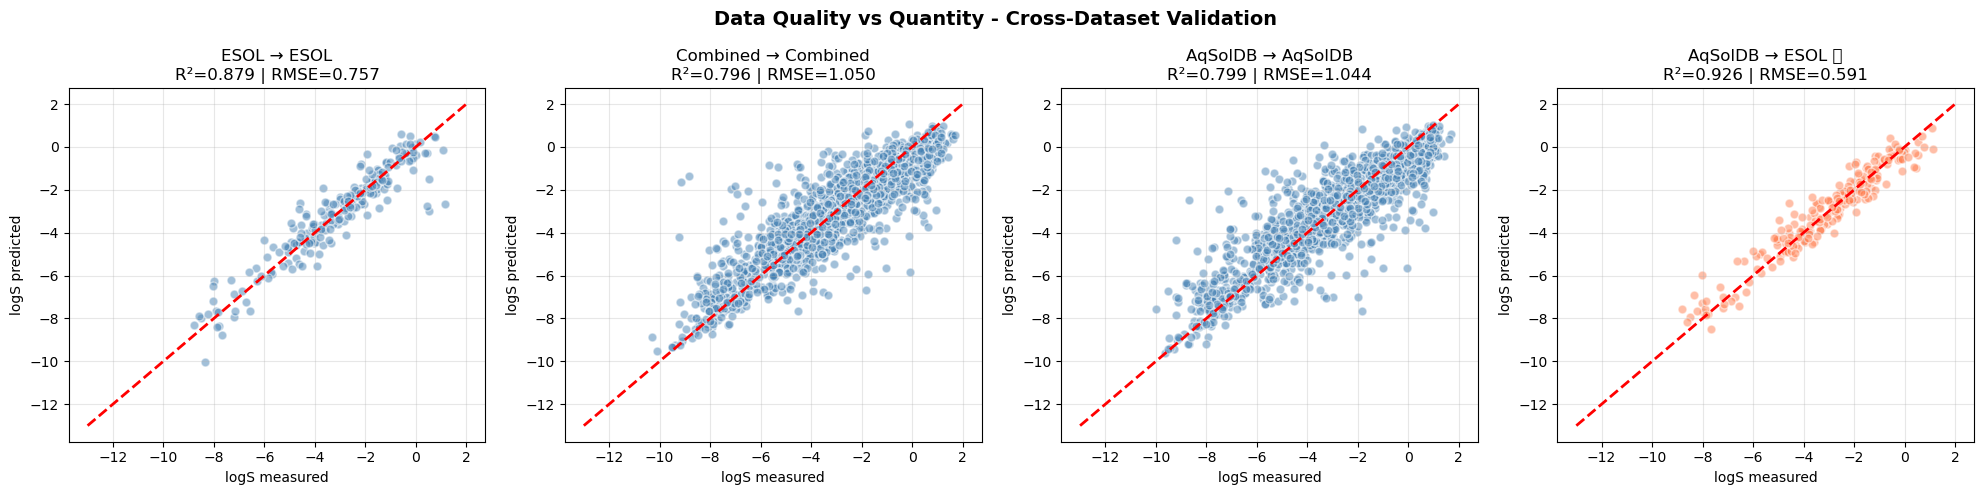

In [43]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, y_true, y_pred, title, r2, rmse in zip(
    axes,
    [y_test_c, y_te_big, y_te, y_test_c],
    [y_pred_xgb, y_pr_big, y_pr_aq, y_pred_aq_on_esol],
    ['ESOL → ESOL', 'Combined → Combined', 'AqSolDB → AqSolDB', 'AqSolDB → ESOL ⭐'],
    [r2_xgb, r2_big, r2_aq, r2_cross],
    [rmse_xgb, rmse_big, rmse_aq, rmse_cross],
):
    color = 'coral' if title == 'AqSolDB → ESOL ⭐' else 'steelblue'
    ax.scatter(y_true, y_pred, alpha=0.5, color=color, edgecolors='white', s=40)
    ax.plot([-13, 2], [-13, 2], 'r--', linewidth=2)
    ax.set_xlabel('logS measured')
    ax.set_ylabel('logS predicted')
    ax.set_title(f'{title}\nR²={r2:.3f} | RMSE={rmse:.3f}')
    ax.grid(True, alpha=0.3)

plt.suptitle('Data Quality vs Quantity - Cross-Dataset Validation', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [45]:
# Entraîner sur AqSolDB sans ESOL
desc_list_no_esol = df_aqsol_no_esol['smiles'].apply(calculer_descripteurs).tolist()
valid_mask_no_esol = [d is not None for d in desc_list_no_esol]

df_aq_no_esol_valid = df_aqsol_no_esol[valid_mask_no_esol].reset_index(drop=True)
desc_no_esol = pd.DataFrame([d for d in desc_list_no_esol if d is not None])
fp_no_esol = np.array([calculer_fingerprint(s) for s in df_aq_no_esol_valid['smiles']])

X_no_esol = np.hstack([fp_no_esol, desc_no_esol.values])
y_no_esol = df_aq_no_esol_valid['logS'].values

# Entraîner sur AqSolDB\ESOL, tester sur ESOL complet
model_xgb_clean = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model_xgb_clean.fit(X_no_esol, y_no_esol)

# Tester sur ESOL complet (test set)
y_pred_clean = model_xgb_clean.predict(X_test_c)
r2_clean = r2_score(y_test_c, y_pred_clean)
rmse_clean = np.sqrt(mean_squared_error(y_test_c, y_pred_clean))

print(f"XGBoost ESOL → ESOL              → R² : {r2_xgb:.3f} | RMSE : {rmse_xgb:.3f}")
print(f"XGBoost AqSolDB → ESOL (leakage) → R² : {r2_cross:.3f} | RMSE : {rmse_cross:.3f}")
print(f"XGBoost AqSolDB\ESOL → ESOL      → R² : {r2_clean:.3f} | RMSE : {rmse_clean:.3f}")

XGBoost ESOL → ESOL              → R² : 0.879 | RMSE : 0.757
XGBoost AqSolDB → ESOL (leakage) → R² : 0.926 | RMSE : 0.591
XGBoost AqSolDB\ESOL → ESOL      → R² : 0.906 | RMSE : 0.668


C:\Users\coure\AppData\Local\Temp\ipykernel_11076\1394717705.py:21: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\coure\anaconda3\envs\chemml\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


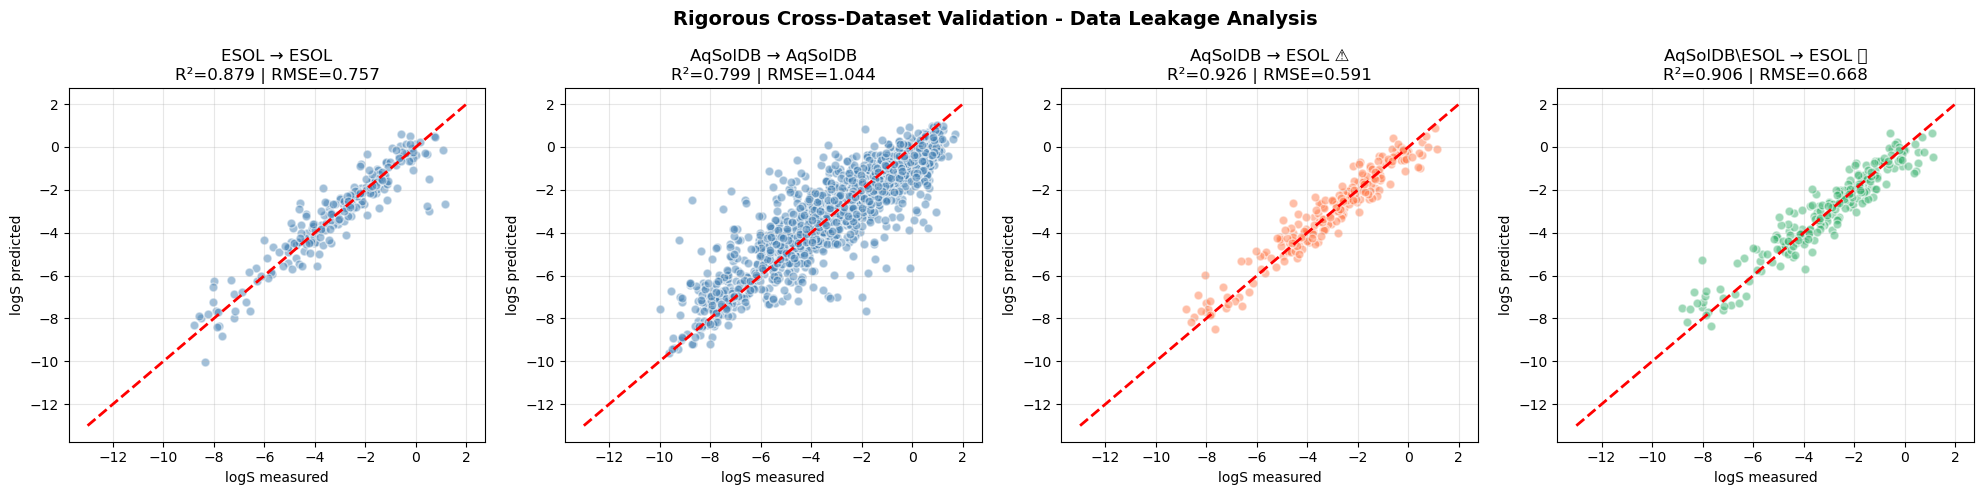

In [46]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, y_true, y_pred, title, r2, rmse, color in zip(
    axes,
    [y_test_c, y_te, y_test_c, y_test_c],
    [y_pred_xgb, y_pr_aq, y_pred_aq_on_esol, y_pred_clean],
    ['ESOL → ESOL', 'AqSolDB → AqSolDB', 'AqSolDB → ESOL ⚠️', 'AqSolDB\\ESOL → ESOL ✅'],
    [r2_xgb, r2_aq, r2_cross, r2_clean],
    [rmse_xgb, rmse_aq, rmse_cross, rmse_clean],
    ['steelblue', 'steelblue', 'coral', 'mediumseagreen']
):
    ax.scatter(y_true, y_pred, alpha=0.5, color=color, edgecolors='white', s=40)
    ax.plot([-13, 2], [-13, 2], 'r--', linewidth=2)
    ax.set_xlabel('logS measured')
    ax.set_ylabel('logS predicted')
    ax.set_title(f'{title}\nR²={r2:.3f} | RMSE={rmse:.3f}')
    ax.grid(True, alpha=0.3)

plt.suptitle('Rigorous Cross-Dataset Validation - Data Leakage Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Data Quality vs Quantity: A Key Finding

Training XGBoost on larger datasets does not automatically improve internal metrics —
AqSolDB (9980 molecules) performs worse than ESOL (1128 molecules) when evaluated 
on their own test sets. However, **external validation tells a different story**.

### Internal metrics (model tested on its own dataset)
| Dataset | Molecules | R² | RMSE |
|---|---|---|---|
| ESOL | 1128 | 0.879 | 0.757 |
| AqSolDB | 9980 | 0.799 | 1.044 |
| Combined | 10504 | 0.796 | 1.050 |

### External validation and data leakage analysis
604 molecules from ESOL were found in AqSolDB. To ensure rigorous evaluation,
the model was retrained on AqSolDB with ESOL molecules removed (AqSolDB\ESOL),
then tested on the full ESOL test set.

| Model | Trained on | Tested on | R² | RMSE | Note |
|---|---|---|---|---|---|
| XGBoost | ESOL | ESOL | 0.879 | 0.757 | Baseline |
| XGBoost | AqSolDB | AqSolDB | 0.799 | 1.044 | Internal |
| XGBoost | AqSolDB | ESOL | 0.926 | 0.591 | ⚠️ Leakage |
| XGBoost | AqSolDB\ESOL | ESOL | **0.906** | **0.668** | ✅ Rigorous |

### Key insights
- The leakage inflated R² by only 0.02 — the generalization gain is real
- More diverse training data produces more robust, better generalizing models
- Internal R² alone is insufficient to evaluate a model's true predictive power
- External validation on **leak-free** independent datasets is essential in cheminformatics
- 604 overlapping molecules between ESOL and AqSolDB highlight the importance
  of deduplication before any cross-dataset evaluation
- This is consistent with best practices in QSPR model validation (Boobier et al., 2020)

### Conclusion
The AqSolDB-trained model (R²=0.906 on external ESOL data) is our best model
and will be used in the Streamlit application for solubility prediction.